# 02  Feature Engineering

**Goal:** Build the full modelling feature set from raw data.

Covers: call features (3-month forward-assign), usage features (DuckDB aggregation),
temporal/recency features, master table assembly, derived numeric features,
collinearity diagnostic, and IV stability (train vs val).

In [25]:
import subprocess, sys
for pkg in ['feature-engine', 'scikit-learn', 'pyarrow', 'duckdb', 'xgboost']:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [26]:
import warnings; warnings.filterwarnings('ignore')
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import set_config
set_config(transform_output='pandas')

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_style('whitegrid')

from src.config import SEED, PREDICTION_HORIZON_DAYS, LOOKBACK_MONTHS
from src.ingestion import load_raw_data, build_labels, clean_grain
from src.features import (
    compute_call_features, compute_usage_features, compute_temporal_features,
    build_master, add_derived_features, PackageGrouper,
)
from src.pipelines import (
    CAT_COLS, CAT_COLS_AUDIT, ALL_FEATURES_AUDIT, DROPPED_COLLINEAR, WINSOR_COLS,
)
from src.evaluation import categorical_target_summary, iv_band, compute_iv_stability

from sklearn.pipeline import Pipeline
from feature_engine.encoding import RareLabelEncoder, MeanEncoder

## 1. Load Raw Data & Build Labels

In [3]:
customer_info, calls, cease, usage_monthly = load_raw_data('.')
df, DATA_END = build_labels(customer_info, cease, PREDICTION_HORIZON_DAYS)
df = clean_grain(df)
print(f'DATA_END: {DATA_END.date()}')

./customer_info.parquet: (3545538, 12)  |  202,782 customers


./calls.csv: (628437, 5)  |  128,833 customers
./cease.csv: (146363, 5)  |  130,934 customers
Aggregating usage via DuckDB (83M rows)...


usage_monthly: (3168691, 7)


  usage_monthly: dropped 1 IDs not in customer_info


Removed 244,436 already-churned rows. Remaining: 3,301,102
Max cease date in data  : 2024-09-01  (derived, not hard-coded)
Right-censoring guard   : DATA_END = 2024-05-01
Label window closes     : 2024-07-30
Buffer before max cease : 33 days

Overall churn rate (all data)         : 11.01%
Churn rate (DATA_END-clean rows only) : 11.38%


Exact duplicate rows: 8,620  -> dropping


Conflicting (customer, datevalue) rows after exact dedupe: 0


Grain check passed -- 3,292,482 unique (customer, month) rows.
DATA_END: 2024-05-01


## 2. Call Features

Forward-assign: each monthly call aggregate is replicated 3 times with
datevalue offsets +1, +2, +3 months. Grouping by (customer, datevalue) then sums
the 3 preceding months of call activity into a single row, so no look ahead.

Call types are bucketed into: Tech, CS&B, Loyalty, Customer Finance, FTTP, Other.
Per type counts, ratio features, and hold/talk time aggregates are all computed.

In [4]:
call_feats, calls_monthly = compute_call_features(calls, LOOKBACK_MONTHS)
print(call_feats.dtypes)
call_feats.head(3)

calls_monthly: (263810, 11)


call_feats: (651425, 22)
unique_customer_identifier                object
datevalue                         datetime64[ns]
calls_3m_count                             int64
calls_3m_total_talk                      float64
calls_3m_total_hold                      float64
call_Other_3m                               int8
call_cs_b_3m                               int64
call_customer_finance_3m                    int8
call_fttp_3m                                int8
call_loyalty_3m                             int8
call_tech_3m                               int64
calls_3m_avg_talk                        float64
calls_3m_avg_hold                        float64
call_Other_3m_ratio                      float64
call_cs_b_3m_ratio                       float64
call_customer_finance_3m_ratio           float64
call_fttp_3m_ratio                       float64
call_loyalty_3m_ratio                    float64
call_tech_3m_ratio                       float64
calls_3m_loyalty                            

,unique_customer_identifier,datevalue,calls_3m_count,calls_3m_total_talk,calls_3m_total_hold,call_Other_3m,call_cs_b_3m,call_customer_finance_3m,call_fttp_3m,call_loyalty_3m,call_tech_3m,calls_3m_avg_talk,calls_3m_avg_hold,call_Other_3m_ratio,call_cs_b_3m_ratio,call_customer_finance_3m_ratio,call_fttp_3m_ratio,call_loyalty_3m_ratio,call_tech_3m_ratio,calls_3m_loyalty,calls_3m_tech,calls_3m_csb
0,000010b1046f4e80d74bd7ceb4ae23f167ba14cf0b2621...,2023-02-01,2,472.0000,115.0000,0,1,0,0,1,0,236.0000,57.5000,0.0000,0.5000,0.0000,0.0000,0.5000,0.0000,1,0,1
1,000010b1046f4e80d74bd7ceb4ae23f167ba14cf0b2621...,2023-03-01,2,472.0000,115.0000,0,1,0,0,1,0,236.0000,57.5000,0.0000,0.5000,0.0000,0.0000,0.5000,0.0000,1,0,1
2,000010b1046f4e80d74bd7ceb4ae23f167ba14cf0b2621...,2023-04-01,3,1129.0000,228.0000,0,2,0,0,1,0,376.3333,76.0000,0.0000,0.6667,0.0000,0.0000,0.3333,0.0000,1,0,2


 Talk and hold columns are NaN for customers with no calls in the window (result of dividing by zero call count). These are filled to 0 in add_derived_features so the logistic regression pipeline does not impute a positive call duration to someone who never rang in. Also, Gradient boosted models handle NaN natively and are unaffected either way.

## 3. Usage Features

The 83M row usage table is pre aggregated to monthly totals by DuckDB in ingestion.py file.
The same forward assign pattern gives 3 month rolling download/upload totals.
A month-over-month trend feature captures acceleration of usage change.

In [5]:
usage_feats, usage_expanded = compute_usage_features(usage_monthly, LOOKBACK_MONTHS)
usage_feats.head(3)

usage_feats: (3568587, 8)


,unique_customer_identifier,datevalue,usage_3m_total_download,usage_3m_total_upload,usage_3m_days,usage_3m_avg_download,usage_3m_avg_upload,download_trend_mom
0,000010b1046f4e80d74bd7ceb4ae23f167ba14cf0b2621...,2023-01-01,510672.0000,10788.1210,11,46424.7273,980.7383,NaN
1,000010b1046f4e80d74bd7ceb4ae23f167ba14cf0b2621...,2023-02-01,1589996.3280,77350.6350,35,45428.4665,2210.0181,-1452.8803
2,000010b1046f4e80d74bd7ceb4ae23f167ba14cf0b2621...,2023-03-01,3011403.6790,109207.1860,63,47800.0584,1733.4474,5792.7012


 usage_feats has 3,568,587 rows vs the master's 3,292,482. The forward-assign step creates (customer, datevalue) pairs for every month that appears in the usage log, including months where a customer existed in the raw data but does not survive into the final master spine (e.g. they had already ceased by that snapshot, or the snapshot falls outside the clean modelling window). build_master left joins all feature tables onto the master spine, so only rows whose (customer, datevalue) key exists in the spine are retained, the extra 276k rows simply fall off.

## 4. Temporal / Recency Features

- calls_1m_*: last-month call counts pairs with 3-month aggregates to capture acceleration
- usage_3m_download_std / upload_std: standard deviation of monthly usage (volatility signal)

In [6]:
calls_1m, usage_volatility = compute_temporal_features(calls_monthly, usage_expanded)

calls_1m: (263810, 5)


usage_volatility: (3568587, 4)


## 5. Assemble Master Table

All feature tables left-joined onto the (customer, datevalue) spine.
The grain assertion ensures no feature merge fans out rows.

In [7]:
master = build_master(df, call_feats, usage_feats, calls_1m, usage_volatility)
master = add_derived_features(master)
print(f'Master shape: {master.shape}')
print(master[['label', 'tenure_days', 'ooc_days', 'calls_3m_count',
              'usage_3m_avg_download', 'contract_status_risk']].describe())

master: (3292482, 44)  |  label rate: 11.016%


master final shape: (3292482, 69)
Master shape: (3292482, 69)


             label  tenure_days     ooc_days  calls_3m_count  \
count 3292482.0000 3292482.0000 3273795.0000    3292482.0000   
mean        0.1102    2396.8248     118.3491          0.3175   
std         0.3131    1906.4242     890.3017          1.3877   
min         0.0000       1.0000    -729.0000          0.0000   
25%         0.0000     765.0000    -322.0000          0.0000   
50%         0.0000    1743.0000    -115.0000          0.0000   
75%         0.0000    4108.0000     178.0000          0.0000   
max         1.0000   10062.0000    7822.0000        240.0000   

       usage_3m_avg_download  
count           2842191.0000  
mean              11879.3867  
std               12459.9314  
min                   0.0000  
25%                2802.9049  
50%                8255.6417  
75%               16965.8300  
max             1747974.9957  


## 6. Collinearity Diagnostic

The manual drop list DROPPED_COLLINEAR removes 6 features that are exact linear
transforms or redundant variants of retained features. This cell confirms that
decision using the post encoding correlation matrix, it is not the selector.

Dropped: `months_to_ooc`, `tenure_years`, `ooc_days_capped`, `has_dd_cancel`,
`speed_underperformance`, `package_speed`.

In [8]:
_aud = master[master['datevalue'] <= DATA_END].copy()
_aud = _aud.sample(n=min(300_000, len(_aud)), random_state=SEED)
_aud_pkg = PackageGrouper().fit_transform(_aud)

_prep = Pipeline([
    ('rare',   RareLabelEncoder(tol=0.02, n_categories=5,
                               variables=CAT_COLS_AUDIT, missing_values='ignore')),
    ('encode', MeanEncoder(variables=CAT_COLS_AUDIT, missing_values='ignore')),
])
_Xe = _prep.fit_transform(_aud_pkg[ALL_FEATURES_AUDIT], _aud_pkg['label'])
_Xe = _Xe.apply(pd.to_numeric, errors='coerce').fillna(_Xe.median(numeric_only=True))

corr = _Xe.corr().abs()
pairs = (corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
             .stack().sort_values(ascending=False))
high = pairs[pairs > 0.95]

print(f'Feature pairs with |corr| > 0.95: {len(high)}')
for (a, b), v in high.items():
    flag = '  <- DROPPED' if (a in DROPPED_COLLINEAR or b in DROPPED_COLLINEAR) else ''
    print(f'  {v:.3f}   {a:24s} ~ {b:24s}{flag}')

_retained = [x for x in ALL_FEATURES_AUDIT if x not in DROPPED_COLLINEAR]
print('\nDrop justification — strongest retained-set partner:')
for f in DROPPED_COLLINEAR:
    if f not in corr.index:
        print(f'  {f:24s} (pipeline-internal, skipped)')
        continue
    c = corr.loc[f, [x for x in _retained if x != f and x in corr.index]].sort_values(ascending=False)
    print(f'  {f:24s} max|corr| = {c.iloc[0]:.2f}  with {c.index[0]}')

Feature pairs with |corr| > 0.95: 3
  1.000   contract_dd_cancels      ~ has_dd_cancel             <- DROPPED
  1.000   ooc_days                 ~ months_to_ooc             <- DROPPED
  1.000   tenure_days              ~ tenure_years              <- DROPPED

Drop justification — strongest retained-set partner:
  months_to_ooc            max|corr| = 1.00  with ooc_days
  tenure_years             max|corr| = 1.00  with tenure_days
  ooc_days_capped          max|corr| = 0.86  with is_ooc
  has_dd_cancel            max|corr| = 1.00  with contract_dd_cancels
  speed_underperformance   max|corr| = 0.62  with line_speed
  package_speed            (pipeline-internal, skipped)


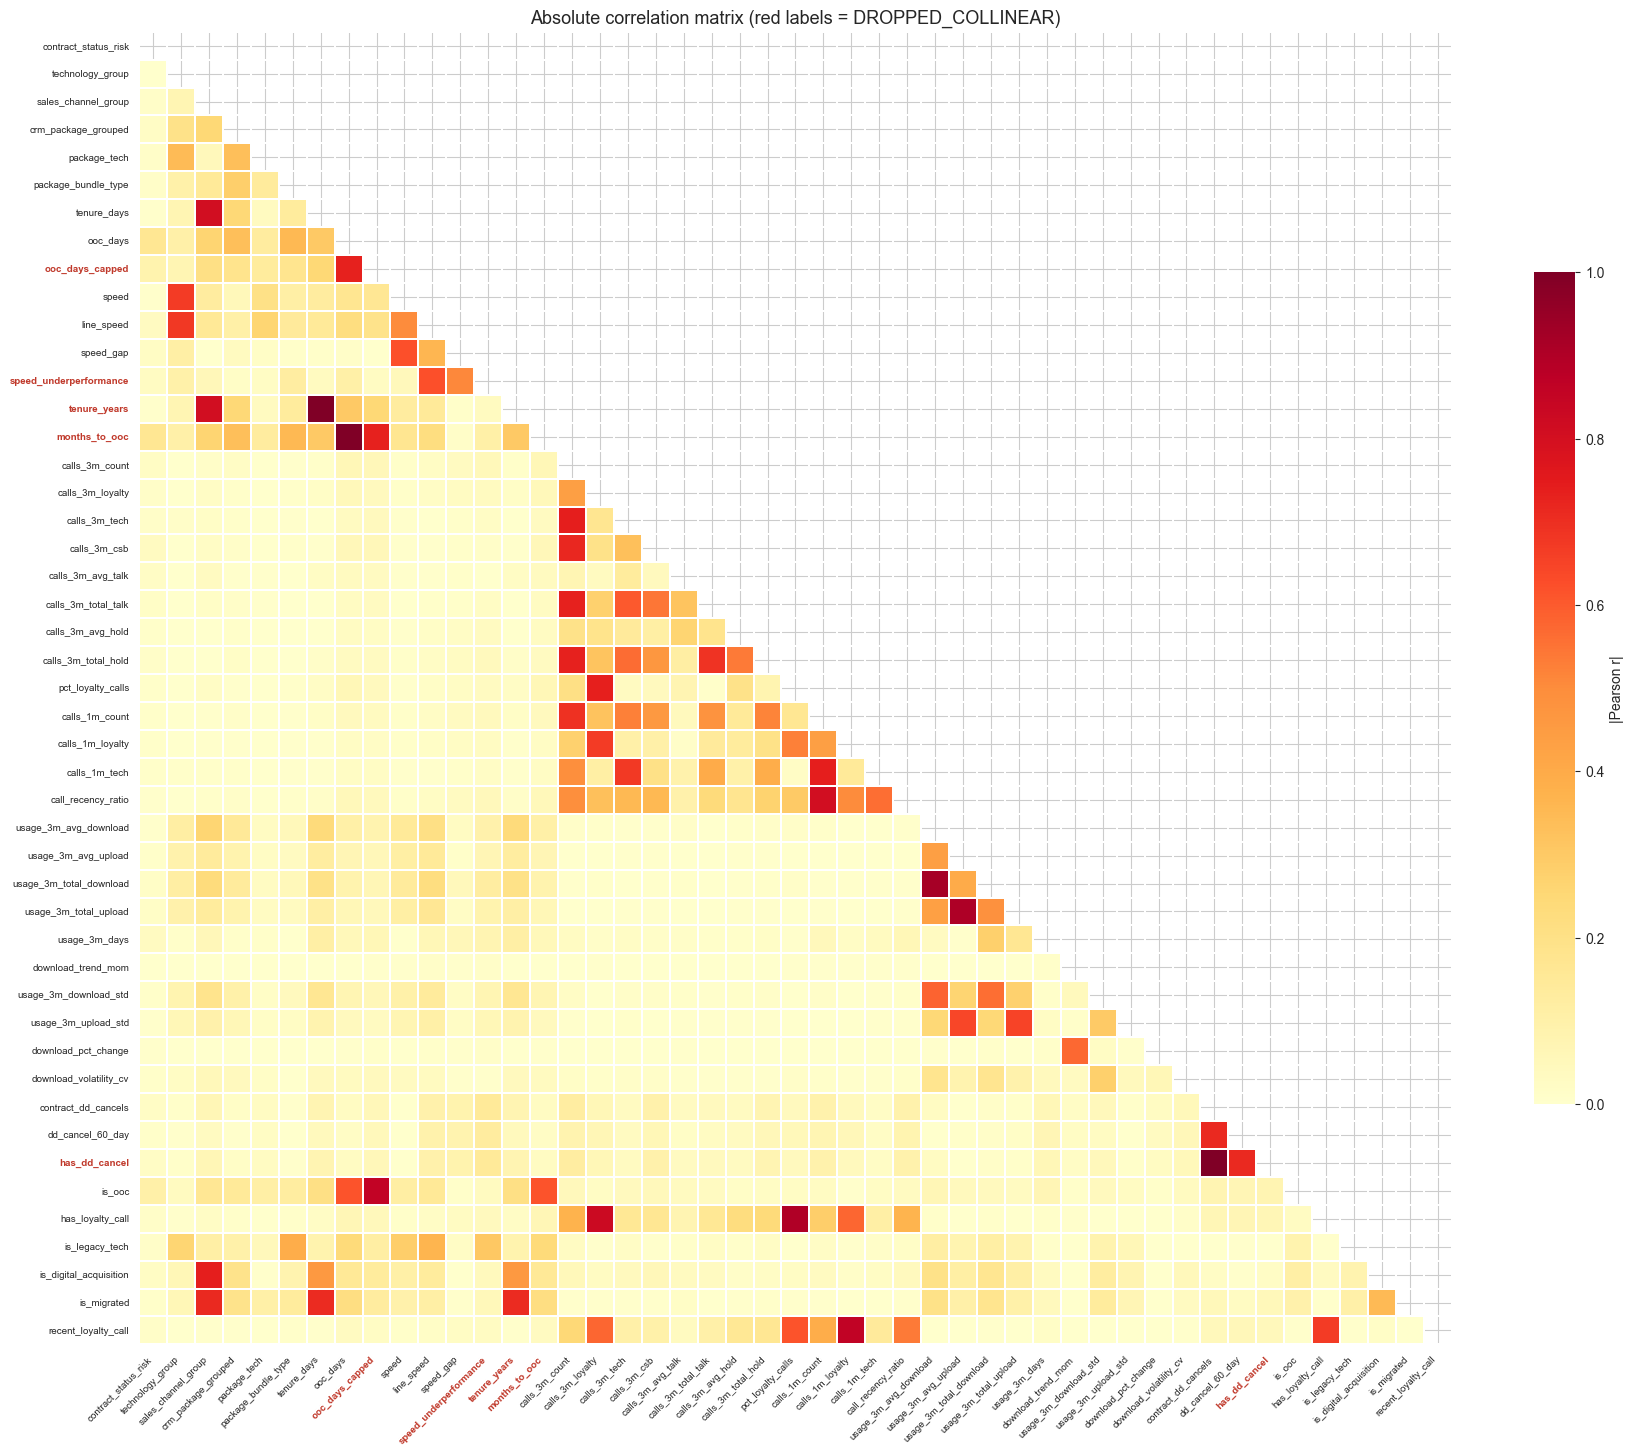

In [9]:
_mask = np.triu(np.ones(corr.shape, dtype=bool))
fig, ax = plt.subplots(figsize=(18, 15))
sns.heatmap(corr, mask=_mask, ax=ax, cmap='YlOrRd', vmin=0, vmax=1,
            linewidths=0.3, linecolor='white', square=True,
            cbar_kws={'shrink': 0.6, 'label': '|Pearson r|'}, annot=False)
for tick in ax.get_xticklabels() + ax.get_yticklabels():
    if tick.get_text() in DROPPED_COLLINEAR:
        tick.set_color('#c0392b'); tick.set_fontweight('bold')
ax.set_title('Absolute correlation matrix (red labels = DROPPED_COLLINEAR)', fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=7); plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.savefig('collinearity_heatmap.png', dpi=130, bbox_inches='tight'); plt.show()

## 7. IV Stability (Train vs Validation)

IV and Spearman ρ computed on a temporal train/val split (last 3 months = val).
An IV ratio near 1.0 and high ρ means the feature signal is stable over time.
Unstable features (IV_ratio < 0.5 or ρ < 0.7) would be candidates for review.

In [10]:
stability, train_c, val_c = compute_iv_stability(
    master, CAT_COLS, DATA_END, val_months=3)
print('\nStability summary:')
print(stability.to_string(index=False))

Val cutoff: 2024-03-01
Train: 2,712,046 rows  churn 11.29%
Val:    270,800 rows  churn 12.35%



Stability summary:
             feature  cardinality  IV_train  IV_val  IV_ratio  spearman_rho     band_train       band_val
contract_status_risk            3    0.8558  0.6051    0.7071        1.0000     suspicious     suspicious
 sales_channel_group            8    0.2192  0.4276    1.9510        0.9048         medium         strong
 crm_package_grouped           11    0.0303  0.1883    6.2045        0.8273           weak         medium
        package_tech            8    0.0125  0.1018    8.1504        0.8154 not predictive         medium
 package_bundle_type            6    0.0101  0.1055   10.4808        0.8286 not predictive         medium
    technology_group            3    0.0009  0.0113   12.6968       -1.0000 not predictive not predictive


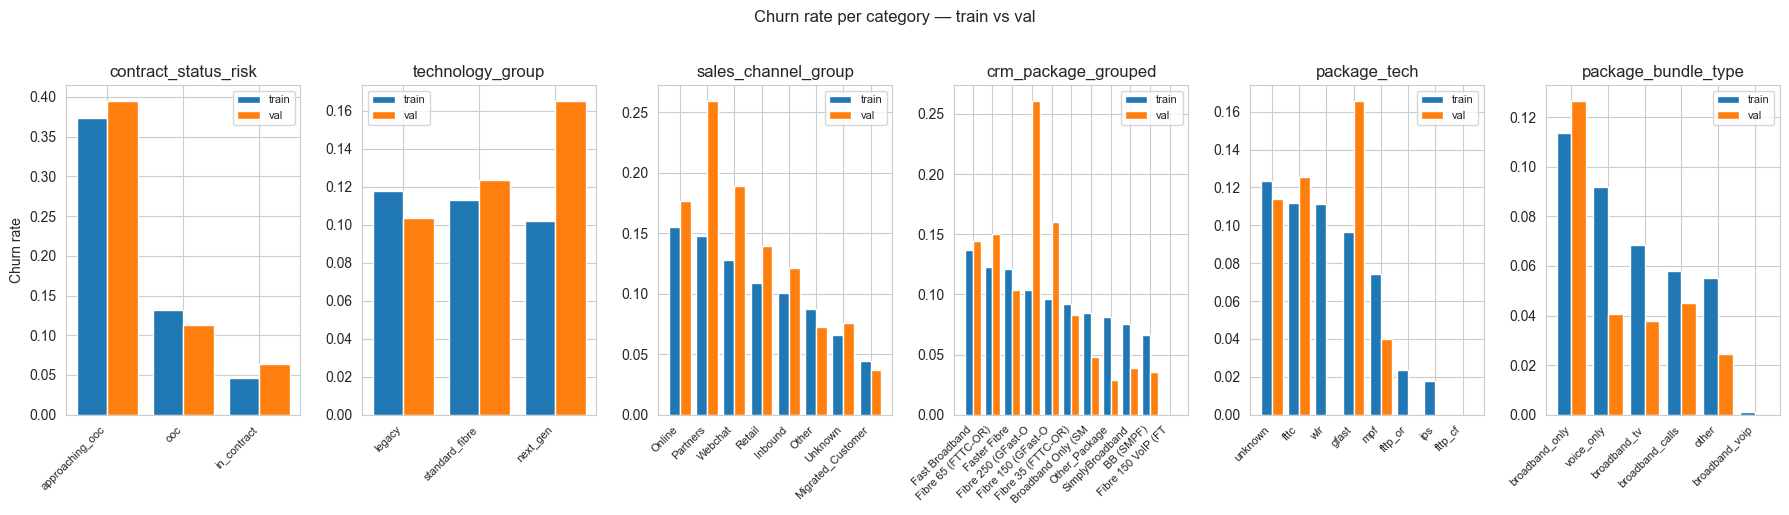

In [11]:
# Per-feature churn-rate bar charts: train vs val
fig, axes = plt.subplots(1, len(CAT_COLS), figsize=(18, 5))
for ax, col in zip(axes, CAT_COLS):
    t_sum = categorical_target_summary(train_c, col).head(12)
    cats  = t_sum.index.tolist()
    v_sum = categorical_target_summary(val_c, col).reindex(cats)
    x     = np.arange(len(cats))
    ax.bar(x - 0.2, t_sum['mean_target'].values, 0.4, label='train', color='C0')
    ax.bar(x + 0.2, v_sum['mean_target'].values, 0.4, label='val',   color='C1')
    ax.set_xticks(x)
    ax.set_xticklabels([str(c)[:18] for c in cats], rotation=45, ha='right', fontsize=8)
    ax.set_title(col); ax.legend(fontsize=8)
axes[0].set_ylabel('Churn rate')
plt.suptitle('Churn rate per category — train vs val', y=1.02)
plt.tight_layout(); plt.show()

WoE sign convention  `categorical_target_summary` uses ln(non_events / events) — positive WoE signals lower churn risk. Feature-engine's `WoEEncoder` (used in the **LR pipeline** only, the boosting models use `MeanEncoder` instead) uses ln(p_churn / p_stay), the opposite sign. IV is sign invariant and unaffected, but if you cross reference EDA WoE values against logistic regression coefficients, the signs will appear flipped. This is expected.

## 8. Save Master Table

In [12]:
os.makedirs('artifacts', exist_ok=True)
master.to_parquet('artifacts/master.parquet', index=False, engine='pyarrow')
with open('artifacts/data_end.txt', 'w') as f:
    f.write(str(DATA_END.date()))
print(f'Saved artifacts/master.parquet  ({master.shape[0]:,} rows, {master.shape[1]} cols)')
print(f'Saved artifacts/data_end.txt    ({DATA_END.date()})')

Saved artifacts/master.parquet  (3,292,482 rows, 69 cols)
Saved artifacts/data_end.txt    (2024-05-01)


The key features are temporally stable: contract_status_risk holds a Spearman ρ of 1.0 between train and validation splits; sales_channel_group stays strong. Stable IV over time means the predictive structure is durable, the model should generalise to next month rather than just re describing last month.